In [1]:
import kiauhoku as kh
grid = kh.load_grid("yrec")

In [2]:
import numpy as np
from scipy.interpolate import interp1d
import pandas as pd

def to_isochrone_grid(self, ages=None):
    # automatically generate ages if not provided
    if ages is None:
        ages = [0.001, 0.01, *np.linspace(0.1, 15, 150).round(1)]

    age_label = self.eep_params["age"]
    index = self.index.droplevel(-1).drop_duplicates()

    iso_idx = pd.MultiIndex.from_product([*self.index.levels[:-1], ages],
        names=[*self.index.names[:-1], age_label])
    iso_grid = pd.DataFrame(columns=self.columns.drop(age_label), index=iso_idx)
    
    for idx in index:
        track = self.loc[idx].set_index(age_label)
        resampled_track = interp1d(track.index.values, track.values, axis=0, bounds_error=False)(ages)
        iso_grid.loc[idx] = resampled_track

    return iso_grid.reorder_levels(iso_grid.index.names[::-1]).sort_index().dropna()
    
iso_grid = to_isochrone_grid(grid)
iso_grid

L/Lsun    R/Rsun      logg Log Teff(K)  \
Age(Gyr) initial_met initial_mass                                             
0.001    -1.0        0.6           0.051008  0.236747  3.742389    3.656006   
                     0.7           0.150072  0.257894  3.767041    3.670198   
                     0.8           0.239596  0.278691   3.78344    3.682181   
                     0.9           0.319385  0.298713  3.794547    3.692117   
                     1.0           0.391539  0.318074  3.801584    3.700475   
...                                     ...       ...       ...         ...   
15.000    0.5        0.6          -1.182138 -0.254846  4.725574    3.593516   
                     0.7          -0.880303 -0.185946  4.654721    3.634525   
                     0.8          -0.560225 -0.115062  4.570945    3.679102   
                     0.9          -0.207706  -0.02388  4.439734    3.721641   
                     1.0           0.728708  0.544064  3.349604    3.671772   

                                  mass_conv_core mass_conv_envelope logT(cen)  \
Age(Gyr) initial_met initial_mass                                               
0.001    -1.0        0.6                     0.0                0.6  6.419032   
                     0.7                     0.0                0.7  6.463748   
                     0.8                     0.0                0.8  6.500113   
                     0.9                     0.0            0.86168  6.528401   
                     1.0                     0.0           0.887999  6.549315   
...                                          ...                ...       ...   
15.000    0.5        0.6                     0.0            0.14183  6.999987   
                     0.7                     0.0           0.110187  7.055959   
                     0.8                     0.0           0.084319  7.126743   
                     0.9                     0.0           0.064914  7.230832   
                     1.0                     0.0            0.75636  7.456573   

                                  logrho(cen)  logP(cen)      Xcen  ...  \
Age(Gyr) initial_met initial_mass                                   ...   
0.001    -1.0        0.6             0.009127  14.567296  0.747065  ...   
                     0.7             0.011484  14.614967  0.747065  ...   
                     0.8             0.006259  14.646576  0.747065  ...   
                     0.9            -0.000373  14.668581  0.747065  ...   
                     1.0            -0.003732  14.686384  0.747065  ...   
...                                       ...        ...       ...  ...   
15.000    0.5        0.6             1.907562  16.961256  0.494956  ...   
                     0.7             1.995516  17.073469  0.417458  ...   
                     0.8             2.142241  17.235763  0.294933  ...   
                     0.9             2.423878  17.506041  0.081102  ...   
                     1.0             4.860343  20.624432       0.0  ...   

                                      Ysurf     Zsurf  \
Age(Gyr) initial_met initial_mass                       
0.001    -1.0        0.6           0.250993   0.00189   
                     0.7           0.250993   0.00189   
                     0.8           0.250993   0.00189   
                     0.9           0.250993   0.00189   
                     1.0           0.250993   0.00189   
...                                     ...       ...   
15.000    0.5        0.6           0.316437  0.050634   
                     0.7           0.316437  0.050634   
                     0.8           0.316437  0.050634   
                     0.9           0.316437  0.050634   
                     1.0           0.334296  0.050634   

                                                                           Jtot(cgs)  \
Age(Gyr) initial_met initial_mass                                                      
0.001    -1.0        0.6           26276938637399947529476100

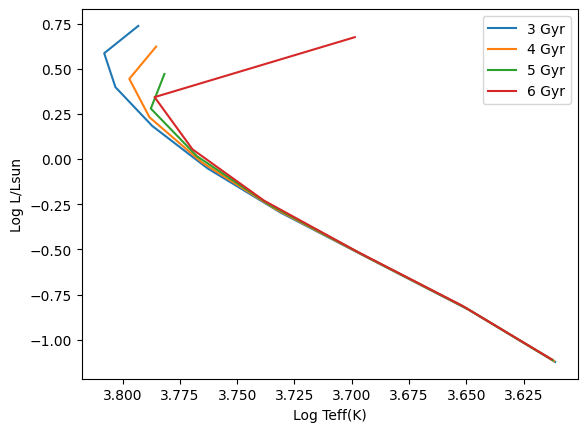

In [3]:
import matplotlib.pyplot as plt

t = [3, 4, 5, 6]
for age in t:
    iso = iso_grid.loc[age, 0]
    plt.plot("Log Teff(K)", "L/Lsun", data=iso, label=f"{age} Gyr")

plt.gca().invert_xaxis()
plt.xlabel("Log Teff(K)")
plt.ylabel("Log L/Lsun")
plt.legend();